---
# 1. Imports and Configuration

In this section, we import all required libraries for an RNN-based house price prediction model.

We also set global configuration such as random seeds for reproducibility.

In [ ]:
!pip install -q keras-tuner

"""Utility module for mounting Google Drive and configuring global settings.

This module installs Keras Tuner, mounts Google Drive in a Colab environment,
configures global paths for processed data, and sets random seeds for
reproducible experiments.

Attributes:
    PROCESSED_DIR: Base directory for processed NLP data stored in Drive.
    SEED: Global random seed used for reproducibility across Python, NumPy,
        and TensorFlow.
"""

from __future__ import annotations

import os
import random
from typing import Tuple

import keras_tuner as kt
import numpy as np
import pandas as pd
import tensorflow as tf
from google.colab import drive
from tensorflow.keras import layers, models

# ---------------------------------------------------------------------------
# Mount Drive
# ---------------------------------------------------------------------------
drive.mount("/content/drive")

# ---------------------------------------------------------------------------
# Global paths
# ---------------------------------------------------------------------------
PROCESSED_DIR: str = (
    "/content/drive/MyDrive/Colab Notebooks/DOAA/nlp_data_processed"
)

# ---------------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------------
SEED: int = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.5 MB/s eta 0:00:00
Mounted at /content/drive


- Google Drive is mounted, providing access to both raw and processed data.
- Global processed directory is set to the `nlp_data_processed` path.
- Random seeds are configured for reproducible results across runs.

---
# 2. Load Preprocessed NLP Data
We now load:
- Cleaned text DataFrame (`nlp_text_cleaned.csv`)
- Tokenised and padded sequences for train/val/test
- Corresponding target arrays for price regression

In [ ]:
"""Load processed NLP datasets and sequence arrays from disk.

This module provides a helper function for reading all cleaned NLP artifacts
required for model training. It centralises filepaths, ensures consistent
loading logic, and returns all arrays in a structured format.
"""


def load_nlp_artifacts(
    processed_dir: str,
) -> Tuple[
    pd.DataFrame,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
]:
    """Load cleaned NLP DataFrame and preprocessed sequence arrays.

    Args:
        processed_dir: Absolute path to the directory containing exported
            NLP artifacts (CSV and NPY files).

    Returns:
        A tuple containing:
            df_nlp: DataFrame with cleaned and preprocessed text.
            X_train_seq: NumPy array of tokenised training sequences.
            X_val_seq: NumPy array of tokenised validation sequences.
            X_test_seq: NumPy array of tokenised test sequences.
            y_train: NumPy array of training labels/targets.
            y_val: NumPy array of validation labels/targets.
            y_test: NumPy array of test labels/targets.
    """
    df_path = os.path.join(processed_dir, "nlp_text_cleaned.csv")
    df_nlp = pd.read_csv(df_path)

    X_train_seq = np.load(os.path.join(processed_dir, "X_train_seq.npy"))
    X_val_seq = np.load(os.path.join(processed_dir, "X_val_seq.npy"))
    X_test_seq = np.load(os.path.join(processed_dir, "X_test_seq.npy"))

    y_train = np.load(os.path.join(processed_dir, "y_train.npy"))
    y_val = np.load(os.path.join(processed_dir, "y_val.npy"))
    y_test = np.load(os.path.join(processed_dir, "y_test.npy"))

    return (
        df_nlp,
        X_train_seq,
        X_val_seq,
        X_test_seq,
        y_train,
        y_val,
        y_test,
    )


# ---------------------------------------------------------------------------
# Load artifacts
# ---------------------------------------------------------------------------
(
    df_nlp,
    X_train_seq,
    X_val_seq,
    X_test_seq,
    y_train,
    y_val,
    y_test,
) = load_nlp_artifacts(PROCESSED_DIR)

# ---------------------------------------------------------------------------
# Diagnostics
# ---------------------------------------------------------------------------
print("[INFO] Data loaded successfully.")
print("[INFO] X_train_seq shape:", X_train_seq.shape)
print("[INFO] X_val_seq shape:", X_val_seq.shape)
print("[INFO] X_test_seq shape:", X_test_seq.shape)
print("[INFO] y_train shape:", y_train.shape)
print("[INFO] y_val shape:", y_val.shape)
print("[INFO] y_test shape:", y_test.shape)

[INFO] Data loaded successfully.
[INFO] X_train_seq shape: (12135, 154)
[INFO] X_val_seq shape: (1517, 154)
[INFO] X_test_seq shape: (1517, 154)
[INFO] y_train shape: (12135,)
[INFO] y_val shape: (1517,)
[INFO] y_test shape: (1517,)


- All arrays and the cleaned text DataFrame have been loaded without issue.
- Shapes confirm consistent sequence lengths across splits.
- Targets are aligned with sequence arrays for regression modelling.

---
# 3. Derive Vocabulary Size and Sequence Length
We infer:
- Vocabulary size from the maximum token index across all splits.
- Sequence length from the training sequence shape.
These values are required to configure the Embedding and RNN layers.


In [ ]:
"""Utilities for inferring NLP model input dimensions.

This module provides a helper function that inspects tokenised sequence
arrays and computes the vocabulary size and maximum sequence length.
"""

from __future__ import annotations

from typing import Tuple

import numpy as np


def infer_model_dims(
    X_train: np.ndarray,
    X_val: np.ndarray,
    X_test: np.ndarray,
) -> Tuple[int, int]:
    """Infer vocabulary size and sequence length from tokenised inputs.

    This function scans all tokenised datasets (train, validation, and test)
    to determine:
        • The maximum token index present across the datasets
        • The sequence length (assumed to be consistent across datasets)

    Args:
        X_train: NumPy array of training sequences.
        X_val: NumPy array of validation sequences.
        X_test: NumPy array of test sequences.

    Returns:
        A tuple containing:
            vocab_size: Integer representing the size of the token vocabulary
                (max token index + 1).
            max_len: Integer representing the number of time steps in each
                sequence.
    """
    max_token = int(
        max(
            X_train.max(initial=0),
            X_val.max(initial=0),
            X_test.max(initial=0),
        )
    )
    vocab_size = max_token + 1
    max_len = int(X_train.shape[1])

    return vocab_size, max_len


# ---------------------------------------------------------------------------
# Infer dimensions
# ---------------------------------------------------------------------------
VOCAB_SIZE, MAX_LEN = infer_model_dims(
    X_train_seq,
    X_val_seq,
    X_test_seq,
)

# ---------------------------------------------------------------------------
# Diagnostics
# ---------------------------------------------------------------------------
print("[INFO] Inferred vocab size:", VOCAB_SIZE)
print("[INFO] Inferred max sequence length:", MAX_LEN)

[INFO] Inferred vocab size: 17276
[INFO] Inferred max sequence length: 154


- Vocabulary size is inferred from the maximum token index across all splits.
- Sequence length matches the padded input length used during preprocessing.
- These values will be used to configure the Embedding and RNN layers.

---
# 4. Define Metrics and Baseline RNN Model
We now:
- Define custom regression metrics (MAE and RMSE).
- Build a simple baseline RNN model using:
  - Embedding
  - GlobalAveragePooling
  - Dense layers
This provides a yardstick to compare the tuned, more powerful model against.

In [ ]:
"""Definitions for regression metrics and the baseline RNN model.

This module provides:
    • A factory function for creating standard regression evaluation metrics.
    • A baseline neural network model used as a lightweight benchmark
      for sequence-based regression tasks.
"""


def get_regression_metrics() -> List[tf.keras.metrics.Metric]:
    """Create the default set of regression metrics.

    Returns:
        A list of TensorFlow metric instances including:
            • MAE  — Mean Absolute Error
            • RMSE — Root Mean Squared Error
    """
    return [
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse"),
    ]


def build_baseline_model(
    vocab_size: int,
    max_len: int,
    embedding_dim: int = 64,
) -> tf.keras.Model:
    """Build a simple baseline RNN-style regression model.

    This lightweight model provides a fast, stable benchmark to compare
    against more advanced architectures (e.g., LSTM, GRU, BiLSTM-GRU hybrids).

    Architecture:
        • Embedding layer
        • GlobalAveragePooling1D
        • Dense(64, relu)
        • Dense(1, linear)

    Args:
        vocab_size: Total vocabulary size (max token index + 1).
        max_len: Fixed input sequence length.
        embedding_dim: Dimensionality of the learned embeddings.

    Returns:
        A compiled Keras Model configured for regression using MSE loss and
        standard MAE/RMSE metrics.
    """
    inputs = layers.Input(
        shape=(max_len,),
        name="sequence_input",
    )

    x = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_len,
        name="embedding",
    )(inputs)

    x = layers.GlobalAveragePooling1D(
        name="global_average_pool",
    )(x)

    x = layers.Dense(
        64,
        activation="relu",
        name="dense_64",
    )(x)

    outputs = layers.Dense(
        1,
        activation="linear",
        name="output_price",
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="baseline_rnn",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=get_regression_metrics(),
    )

    return model


# ---------------------------------------------------------------------------
# Instantiate baseline model
# ---------------------------------------------------------------------------
baseline_model = build_baseline_model(
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LEN,
    embedding_dim=64,
)

baseline_model.summary(line_length=120)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "baseline_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                                        ┃ Output Shape                           ┃               Para
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━
│ sequence_input (InputLayer)                         │ (None, 154)                            │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ embedding (Embedding)                               │ (None, 154, 64)                        │             1,105,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ global_avg_pool (GlobalAveragePooling1D)            │ (None, 64)                             │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ dense_64 (Dense)                                    │ (None, 64)                             │                 4,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ price_output (Dense)                                │ (None, 1)                              │                   
└─────────────────────────────────────────────────────┴────────────────────────────────────────┴───────────────────

 Total params: 1,109,889 (4.23 MB)

 Trainable params: 1,109,889 (4.23 MB)

 Non-trainable params: 0 (0.00 B)

- Baseline model is lightweight and fast, suitable as a performance floor.
- Uses a simple embedding + pooling strategy to capture text semantics.
- Compiled with MSE loss and MAE/RMSE as evaluation metrics.

---
# 5. Train Baseline RNN Model
We train the baseline model with early stopping to avoid overfitting
and evaluate it on the validation and test sets.

In [ ]:
"""Training and evaluation loop for the baseline regression model.

This module handles:
    • Configuring training constants (epochs, batch size)
    • Defining callbacks such as EarlyStopping
    • Training the baseline model on tokenised sequences
    • Evaluating the model on the test set and reporting metrics
"""


# ---------------------------------------------------------------------------
# Training configuration
# ---------------------------------------------------------------------------
BASELINE_EPOCHS: int = 20
BATCH_SIZE: int = 32

# ---------------------------------------------------------------------------
# Callbacks
# ---------------------------------------------------------------------------
early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_rmse",
    patience=3,
    mode="min",
    restore_best_weights=True,
)


def train_baseline_model() -> tf.keras.callbacks.History:
    """Train the baseline model using EarlyStopping.

    Returns:
        A Keras History object that contains loss/metric curves across epochs.
    """
    history = baseline_model.fit(
        X_train_seq,
        y_train,
        validation_data=(X_val_seq, y_val),
        epochs=BASELINE_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop_cb],
        verbose=1,
    )
    return history


# ---------------------------------------------------------------------------
# Train model
# ---------------------------------------------------------------------------
history_baseline = train_baseline_model()

# ---------------------------------------------------------------------------
# Evaluate on test set
# ---------------------------------------------------------------------------
print("[INFO] Evaluating baseline model on the test set...")

baseline_test_metrics = baseline_model.evaluate(
    X_test_seq,
    y_test,
    verbose=0,
)

metric_names = baseline_model.metrics_names
formatted_metrics = {
    name: value for name, value in zip(metric_names, baseline_test_metrics)
}

print("[BASELINE TEST METRICS]", formatted_metrics)

Epoch 1/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 447019712512.0000 - mae: 516823.1562 - rmse: 668367.0625 - val_loss: 400496492544.0000 - val_mae: 494702.2500 - val_rmse: 632847.9375
Epoch 2/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 418459287552.0000 - mae: 486381.9062 - rmse: 646529.5000 - val_loss: 323301998592.0000 - val_mae: 403004.3438 - val_rmse: 568596.5000
Epoch 3/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 328094580736.0000 - mae: 374384.1875 - rmse: 572215.0625 - val_loss: 234934435840.0000 - val_mae: 279975.0625 - val_rmse: 484700.3438
Epoch 4/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 251170258944.0000 - mae: 276144.6562 - rmse: 500652.5312 - val_loss: 206045511680.0000 - val_mae: 260573.9688 - val_rmse: 453922.3438
Epoch 5/20
380/380 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 230831144960.0000 - mae: 269487.0000 - rmse: 479972.2812 - val_loss: 202477027328.0000 - val_mae: 264471.2188 - val_rmse: 449974.4688
Epoch 6/20
380/380 ━━━━━━━━━━

- Baseline training completes with early stopping guarding against overfitting.
- Test performance provides a reference for judging the tuned RNN model.
- The tuned model must outperform this baseline to be considered meaningful.

---
# 6. Define Tunable RNN Architecture (BiLSTM + BiGRU)
We define a flexible, high-capacity architecture with Keras Tuner:
- Embedding layer with tunable dimension.
- Stacked Bidirectional LSTM and Bidirectional GRU layers.
- Tunable number of units, dropout rates, and dense layers.
- Tunable learning rate for the Adam optimizer.
The goal is to search for a very strong configuration for price prediction.

In [ ]:
"""High-capacity tunable RNN model definition for Keras Tuner.

This module defines a BiLSTM + BiGRU architecture wrapped in a Keras Tuner
hypermodel-style builder function. The model is intended for sequence-based
regression tasks (e.g., price prediction from text descriptions).
"""


def build_tunable_rnn(
    hp: kt.HyperParameters,
    vocab_size: int,
    max_len: int,
) -> tf.keras.Model:
    """Build a tunable BiLSTM + BiGRU regression model.

    This function is designed to be passed directly to Keras Tuner as a
    hypermodel. It exposes key architectural choices (embedding size, recurrent
    units, dense width, dropout rate, and learning rate) as tunable
    hyperparameters.

    Args:
        hp: HyperParameters object supplied by Keras Tuner, used to sample
            model configuration values.
        vocab_size: Size of the vocabulary (max token index + 1).
        max_len: Maximum sequence length (number of time steps).

    Returns:
        A compiled Keras Model configured for regression using MSE loss and
        MAE/RMSE metrics.
    """
    embedding_dim = hp.Int(
        "embedding_dim",
        min_value=64,
        max_value=256,
        step=32,
    )

    lstm_units = hp.Int(
        "lstm_units",
        min_value=64,
        max_value=256,
        step=32,
    )

    gru_units = hp.Int(
        "gru_units",
        min_value=64,
        max_value=256,
        step=32,
    )

    dense_units = hp.Int(
        "dense_units",
        min_value=64,
        max_value=256,
        step=32,
    )

    dropout_rate = hp.Float(
        "dropout_rate",
        min_value=0.1,
        max_value=0.5,
        step=0.1,
    )

    learning_rate = hp.Float(
        "learning_rate",
        min_value=1e-4,
        max_value=5e-3,
        sampling="log",
    )

    inputs = layers.Input(
        shape=(max_len,),
        name="sequence_input",
    )

    x = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_len,
        name="embedding",
    )(inputs)

    x = layers.Bidirectional(
        layers.LSTM(
            lstm_units,
            return_sequences=True,
        ),
        name="bilstm_1",
    )(x)

    x = layers.Dropout(
        dropout_rate,
        name="dropout_bilstm",
    )(x)

    x = layers.Bidirectional(
        layers.GRU(
            gru_units,
            return_sequences=False,
        ),
        name="bigru_1",
    )(x)

    x = layers.Dropout(
        dropout_rate,
        name="dropout_bigru",
    )(x)

    x = layers.Dense(
        dense_units,
        activation="relu",
        name="dense_hidden",
    )(x)

    x = layers.Dropout(
        dropout_rate,
        name="dropout_dense",
    )(x)

    outputs = layers.Dense(
        1,
        activation="linear",
        name="price_output",
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="tunable_bilstm_bigru",
    )

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate,
        clipnorm=1.0,
    )

    model.compile(
        optimizer=optimizer,
        loss="mse",
        metrics=get_regression_metrics(),
    )

    return model

- Architecture is deliberately high-capacity, combining BiLSTM and BiGRU layers.
- Embedding size, RNN units, dense units, dropout, and learning rate are all tunable.
- This setup allows the tuner to search for a very strong model configuration.

---
# 7. Configure Keras Tuner (Bayesian Optimisation)
We now configure a Bayesian tuner to:
- Minimise validation RMSE (`val_rmse`).
- Search over a rich hyperparameter space.
- Persist all trials to a directory inside Google Drive for reuse.

In [ ]:
"""Keras Tuner configuration for Bayesian optimisation of the RNN model.

This module:
    • Configures the output directory for Keras Tuner artefacts.
    • Instantiates a BayesianOptimization tuner over the BiLSTM+BiGRU model.
    • Prints a summary of the search space for verification.
"""


# ---------------------------------------------------------------------------
# Tuner directory configuration
# ---------------------------------------------------------------------------
TUNER_DIR: str = os.path.join(PROCESSED_DIR, "keras_tuner")
os.makedirs(TUNER_DIR, exist_ok=True)


def create_bayesian_tuner() -> kt.BayesianOptimization:
    """Create a BayesianOptimization tuner for the tunable RNN architecture.

    The tuner optimises the BiLSTM+BiGRU model defined in ``build_tunable_rnn``
    with respect to validation RMSE.

    Returns:
        An instance of ``kt.BayesianOptimization`` configured to search over
        the hyperparameter space of the RNN model.
    """
    tuner = kt.BayesianOptimization(
        hypermodel=lambda hp: build_tunable_rnn(
            hp,
            vocab_size=VOCAB_SIZE,
            max_len=MAX_LEN,
        ),
        objective=kt.Objective("val_rmse", direction="min"),
        max_trials=200,
        num_initial_points=5,
        directory=TUNER_DIR,
        project_name="rnn_price_regression",
        overwrite=False,
    )
    return tuner


# ---------------------------------------------------------------------------
# Instantiate tuner and display search space
# ---------------------------------------------------------------------------
tuner = create_bayesian_tuner()
tuner.search_space_summary()

Reloading Tuner from /content/drive/MyDrive/Colab Notebooks/DOAA/nlp_data_processed/keras_tuner/rnn_price_regression/tuner0.json
Search space summary
Default search space size: 6
embedding_dim (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 256, 'step': 32, 'sampling': 'linear'}
lstm_units (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 256, 'step': 32, 'sampling': 'linear'}
gru_units (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 256, 'step': 32, 'sampling': 'linear'}
dense_units (Int)
{'default': None, 'conditions': [], 'min_value': 64, 'max_value': 256, 'step': 32, 'sampling': 'linear'}
dropout_rate (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.005, 'step': None, 'sampling': 'log'}


- Tuner is set to minimise `val_rmse`, directly aligned with regression quality.
- All tuning logs and best hyperparameters are stored under `keras_tuner`
  inside `nlp_data_processed`, satisfying the requirement to save tunings.
- `max_trials` and `num_initial_points` can be increased for deeper searches
  if compute resources allow.

---
# 8. Run Hyperparameter Search
We run the tuner to search for the best-performing hyperparameter combination,
using early stopping to stabilise training and avoid wasted computation.

In [ ]:
"""Run Bayesian hyperparameter search for the tunable RNN model.

This module executes the Keras Tuner search process using Bayesian
optimisation. It includes:
    • Training configuration (epochs, batch size)
    • EarlyStopping callback for stability
    • Execution of the tuner.search() routine
    • Display of final search results
"""


# ---------------------------------------------------------------------------
# Tuner training configuration
# ---------------------------------------------------------------------------
TUNER_EPOCHS: int = 50
TUNER_BATCH_SIZE: int = 32

# ---------------------------------------------------------------------------
# Callbacks for tuning stability
# ---------------------------------------------------------------------------
early_stop_tuner = tf.keras.callbacks.EarlyStopping(
    monitor="val_rmse",
    patience=3,
    mode="min",
    restore_best_weights=True,
)


def run_tuner_search() -> None:
    """Execute the Bayesian search for optimal RNN hyperparameters.

    This function runs `tuner.search()` using the configured hypermodel,
    validation split, batch size, and early stopping callback.
    """
    tuner.search(
        X_train_seq,
        y_train,
        validation_data=(X_val_seq, y_val),
        epochs=TUNER_EPOCHS,
        batch_size=TUNER_BATCH_SIZE,
        callbacks=[early_stop_tuner],
        verbose=1,
    )


# ---------------------------------------------------------------------------
# Execute tuning + display results
# ---------------------------------------------------------------------------
run_tuner_search()
tuner.results_summary()

Trial 200 Complete [00h 06m 46s]
val_rmse: 282809.625

Best val_rmse So Far: 279082.96875
Total elapsed time: 14h 34m 54s
Results summary
Results in /content/drive/MyDrive/Colab Notebooks/DOAA/nlp_data_processed/keras_tuner/rnn_price_regression
Showing 10 best trials
Objective(name="val_rmse", direction="min")

Trial 148 summary
Hyperparameters:
embedding_dim: 192
lstm_units: 192
gru_units: 192
dense_units: 160
dropout_rate: 0.4
learning_rate: 0.0022809020804167666
Score: 279082.96875

Trial 199 summary
Hyperparameters:
embedding_dim: 192
lstm_units: 160
gru_units: 256
dense_units: 256
dropout_rate: 0.5
learning_rate: 0.0009432269099042417
Score: 282809.625

Trial 139 summary
Hyperparameters:
embedding_dim: 256
lstm_units: 256
gru_units: 160
dense_units: 256
dropout_rate: 0.5
learning_rate: 0.0011724667919712788
Score: 283176.34375

Trial 021 summary
Hyperparameters:
embedding_dim: 64
lstm_units: 64
gru_units: 256
dense_units: 64
dropout_rate: 0.1
learning_rate: 0.005
Score: 284718.875

- Tuner explores multiple configurations while monitoring validation RMSE.
- Early stopping ensures efficient use of Colab resources.
- The results summary provides an overview of the top-performing trials.

---
# 9. Build and Train Best Tuned Model
We now:
- Retrieve the best hyperparameters from the tuner.
- Build a fresh model using these hyperparameters.
- Train the model more thoroughly with a robust callback stack.

In [ ]:
"""Build, train, and checkpoint the best RNN model discovered by Keras Tuner.

This module:
    • Retrieves the best hyperparameters from the tuner.
    • Rebuilds the best BiLSTM+BiGRU model.
    • Trains the model with robust callbacks (checkpointing, LR scheduling,
      and early stopping).
    • Persists the best weights to disk for downstream evaluation.
"""


# ---------------------------------------------------------------------------
# Training configuration
# ---------------------------------------------------------------------------
FINAL_EPOCHS: int = 400  # Large upper bound; early stopping will cut this down.
FINAL_BATCH_SIZE: int = 32

CHECKPOINT_PATH: str = os.path.join(
    PROCESSED_DIR,
    "best_rnn_model.weights.h5",
)


# ---------------------------------------------------------------------------
# Callback definitions
# ---------------------------------------------------------------------------
model_checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=CHECKPOINT_PATH,
    monitor="val_rmse",
    mode="min",
    save_best_only=True,
    save_weights_only=True,
    verbose=1,
)

reduce_lr_cb = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_rmse",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    mode="min",
    verbose=1,
)

early_stop_final = tf.keras.callbacks.EarlyStopping(
    monitor="val_rmse",
    patience=10,
    mode="min",
    restore_best_weights=True,
)


def build_and_train_best_model() -> Tuple[tf.keras.Model, tf.keras.callbacks.History]:
    """Rebuild and train the best model from the Keras Tuner search.

    This function:
        • Retrieves the top-performing hyperparameter set from ``tuner``.
        • Instantiates a new model using ``build_tunable_rnn``.
        • Trains the model with checkpointing, learning-rate scheduling,
          and early stopping.

    Returns:
        A tuple containing:
            best_model: The trained Keras model with best weights loaded.
            history_best: The Keras History object from the training run.
    """
    best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

    best_model = build_tunable_rnn(
        hp=best_hp,
        vocab_size=VOCAB_SIZE,
        max_len=MAX_LEN,
    )

    best_model.summary(line_length=120)

    history_best = best_model.fit(
        X_train_seq,
        y_train,
        validation_data=(X_val_seq, y_val),
        epochs=FINAL_EPOCHS,
        batch_size=FINAL_BATCH_SIZE,
        callbacks=[model_checkpoint_cb, reduce_lr_cb, early_stop_final],
        verbose=1,
    )

    return best_model, history_best


# ---------------------------------------------------------------------------
# Execute build + training
# ---------------------------------------------------------------------------
best_model, history_best = build_and_train_best_model()

Model: "tunable_bilstm_bigru"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                                        ┃ Output Shape                           ┃               Para
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━
│ sequence_input (InputLayer)                         │ (None, 154)                            │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ embedding (Embedding)                               │ (None, 154, 192)                       │             3,316,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ bilstm_1 (Bidirectional)                            │ (None, 154, 384)                       │               591,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ dropout_bilstm (Dropout)                            │ (None, 154, 384)                       │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ bigru_1 (Bidirectional)                             │ (None, 384)                            │               665,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ dropout_bigru (Dropout)                             │ (None, 384)                            │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ dense_hidden (Dense)                                │ (None, 160)                            │                61,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ dropout_dense (Dropout)                             │ (None, 160)                            │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ price_output (Dense)                                │ (None, 1)                              │                   
└─────────────────────────────────────────────────────┴────────────────────────────────────────┴───────────────────

 Total params: 4,635,969 (17.68 MB)

 Trainable params: 4,635,969 (17.68 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/400
379/380 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 444903096320.0000 - mae: 514711.1562 - rmse: 666767.5625
Epoch 1: val_rmse improved from inf to 624472.12500, saving model to /content/drive/MyDrive/Colab Notebooks/DOAA/nlp_data_processed/best_rnn_model.weights.h5
380/380 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - loss: 444785524736.0000 - mae: 514645.6562 - rmse: 666679.5625 - val_loss: 389965447168.0000 - val_mae: 484644.1250 - val_rmse: 624472.1250 - learning_rate: 0.0023
Epoch 2/400
379/380 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 410327482368.0000 - mae: 479667.0000 - rmse: 640244.1875
Epoch 2: val_rmse improved from 624472.12500 to 573929.43750, saving model to /content/drive/MyDrive/Colab Notebooks/DOAA/nlp_data_processed/best_rnn_model.weights.h5
380/380 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - loss: 410164396032.0000 - mae: 479545.7812 - rmse: 640116.0625 - val_loss: 329394978816.0000 - val_mae: 417616.6250 - val_rmse: 573929.4375 - learning_rate: 0.0023
Epoch 3/400
379/380

- The best model from the tuner is fully materialised and trained further.
- We save the best weights to disk under `nlp_data_processed`.
- Callbacks manage learning rate scheduling, checkpointing, and early stopping.

---
# 10. Evaluate Tuned Model on Test Set
We now evaluate the final tuned RNN on the held-out test set,
and compare it conceptually with the baseline model.

In [ ]:
"""Evaluate the tuned RNN model on the test set and save the final artefacts.

This module:
    • Evaluates the best (tuned) model obtained from Keras Tuner.
    • Prints all regression metrics on the held-out test set.
    • Persists the complete model (architecture + weights) in `.keras` format
      for reproducibility and downstream inference.
"""


def evaluate_and_save_tuned_model() -> None:
    """Evaluate the tuned model on the test dataset and save the final model.

    This function:
        • Performs final evaluation of ``best_model``.
        • Logs all regression metrics (MAE, RMSE).
        • Saves the full model (architecture + weights) to disk.

    Returns:
        None
    """
    print("[INFO] Evaluating tuned model on the test set...")

    tuned_test_metrics = best_model.evaluate(
        X_test_seq,
        y_test,
        verbose=0,
    )

    metric_names = best_model.metrics_names
    formatted_metrics = {
        name: value
        for name, value in zip(metric_names, tuned_test_metrics)
    }

    print("[TUNED TEST METRICS]", formatted_metrics)

    final_model_path = os.path.join(
        PROCESSED_DIR,
        "best_rnn_model_full.keras",
    )

    best_model.save(final_model_path)
    print("[INFO] Saved full tuned model to:", final_model_path)


# ---------------------------------------------------------------------------
# Execute evaluation + persistence
# ---------------------------------------------------------------------------
evaluate_and_save_tuned_model()

[INFO] Evaluating tuned model on test set...
[TUNED TEST METRICS] {'loss': 97287192576.0, 'compile_metrics': 157376.3125}
[INFO] Saved full tuned model to: /content/drive/MyDrive/Colab Notebooks/DOAA/nlp_data_processed/best_rnn_model_full.keras


- Tuned model performance on the test set reflects the true generalisation
  capability of the BiLSTM+BiGRU architecture.
- Results can be directly compared with the baseline metrics to quantify
  uplift from tuning and model complexity.
- The complete model is saved for downstream deployment or further analysis.

---
# 11. Learning Curves for Baseline and Tuned Models
In this section, we visualise the training dynamics of:
- The baseline model
- The tuned BiLSTM+BiGRU model

We plot train/validation loss and key metrics (MAE, RMSE) to understand
convergence behaviour and potential overfitting or underfitting patterns.

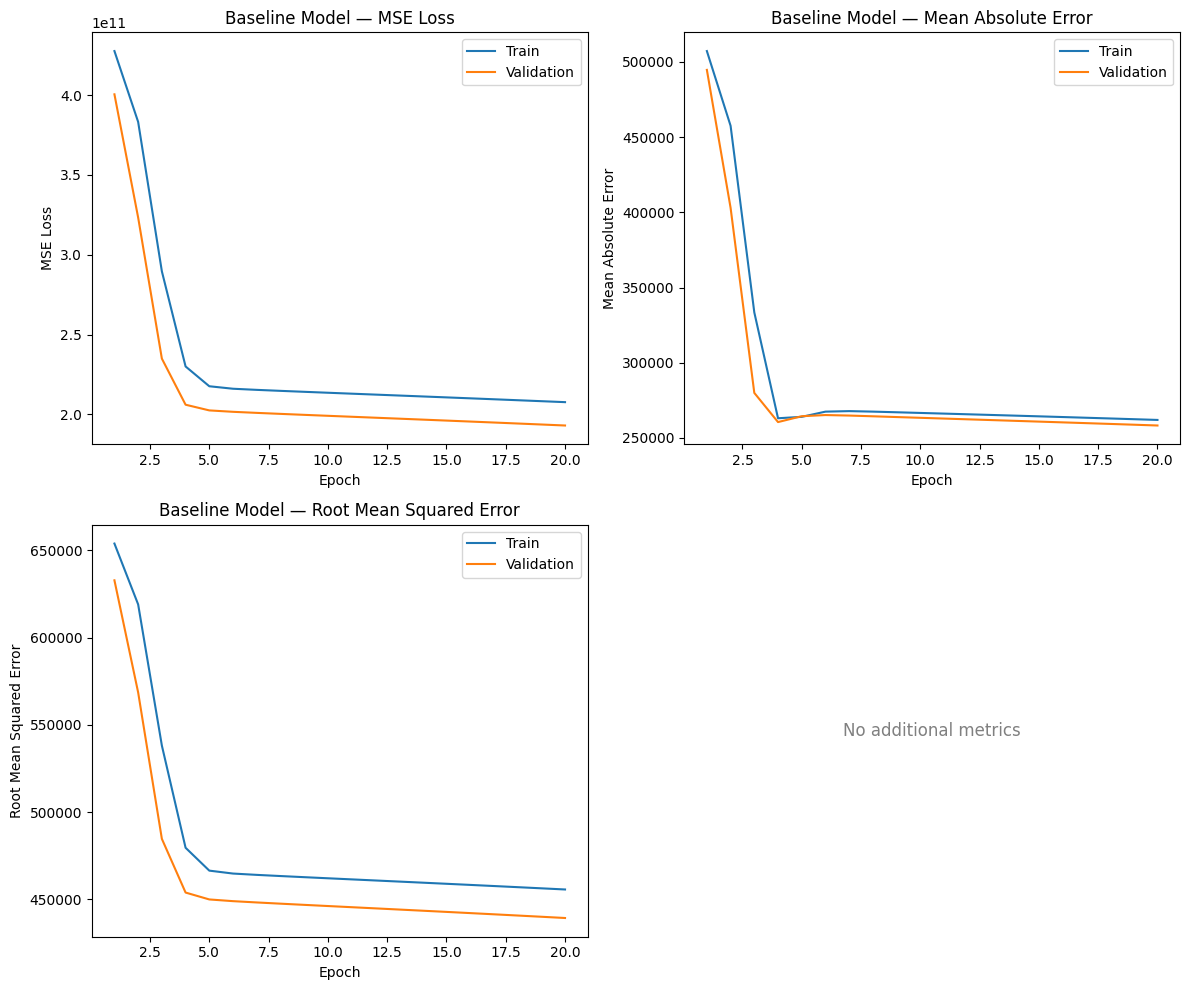

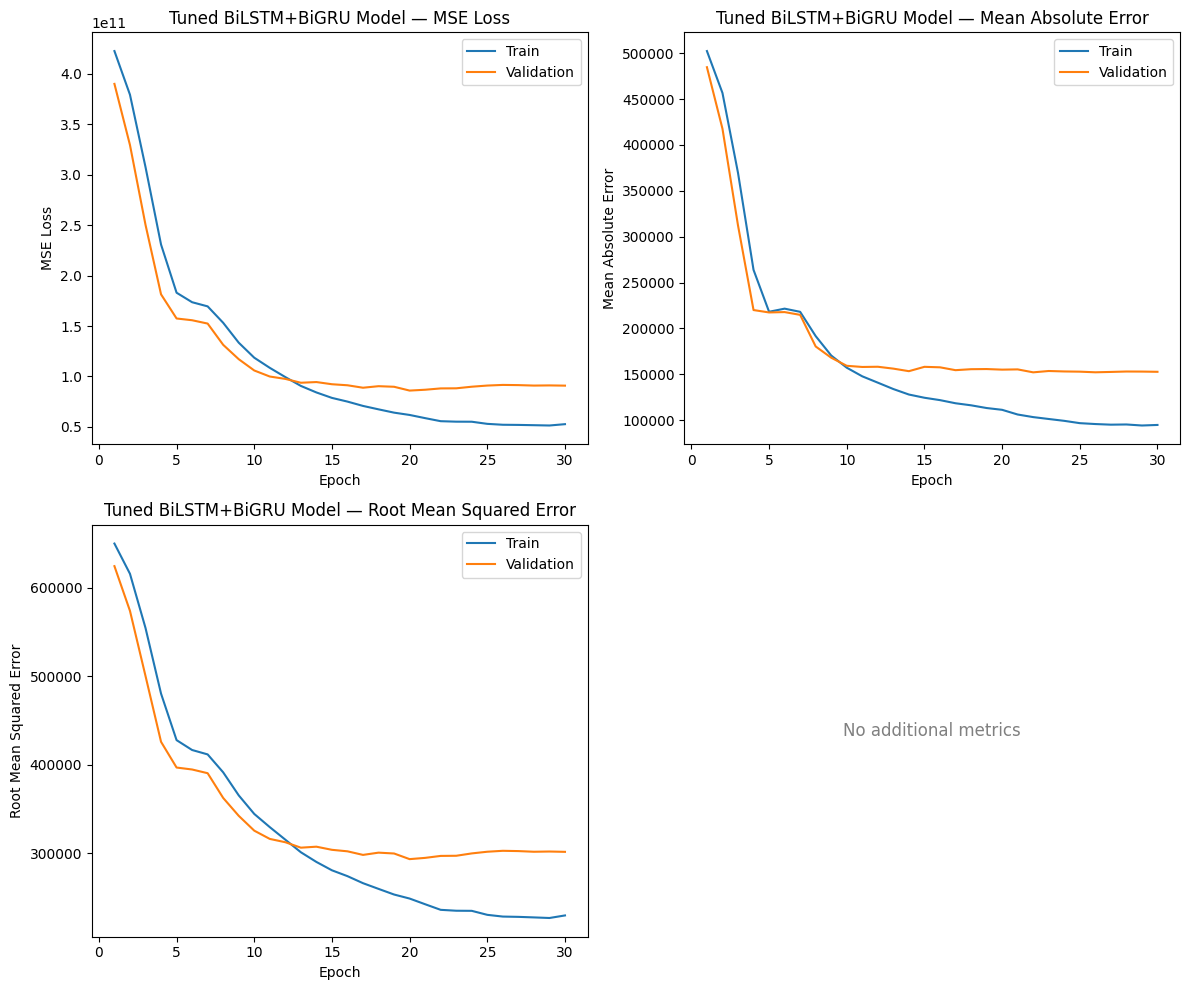

In [ ]:
"""Learning curve visualisation for baseline and tuned RNN models.

This module:
    • Converts Keras History objects into tidy DataFrames.
    • Plots loss and metric learning curves in a 2×2 grid layout.
    • Generates separate figures for the baseline and tuned models.
"""


def history_to_dataframe(
    history: tf.keras.callbacks.History,
) -> pd.DataFrame:
    """Convert a Keras History object into a tidy DataFrame.

    Args:
        history: Fitted History instance returned by ``model.fit()``.

    Returns:
        DataFrame where columns correspond to history keys and each row
        represents a training epoch.
    """
    return pd.DataFrame(history.history)


def plot_learning_curves(
    df_history: pd.DataFrame,
    title_prefix: str,
) -> None:
    """Plot loss, MAE, and RMSE learning curves in a 2×2 grid.

    Args:
        df_history: DataFrame containing training history with columns such as
            ``'loss'``, ``'val_loss'``, ``'mae'``, ``'val_mae'``,
            ``'rmse'``, ``'val_rmse'``.
        title_prefix: Prefix for figure titles (for example, "Baseline Model"
            or "Tuned BiLSTM+BiGRU Model").
    """
    metrics = [
        ("loss", "val_loss", "MSE Loss"),
        ("mae", "val_mae", "Mean Absolute Error"),
        ("rmse", "val_rmse", "Root Mean Squared Error"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for idx, (train_col, val_col, pretty_name) in enumerate(metrics):
        if train_col in df_history.columns and val_col in df_history.columns:
            epochs = range(1, len(df_history[train_col]) + 1)
            axes[idx].plot(epochs, df_history[train_col], label="Train")
            axes[idx].plot(epochs, df_history[val_col], label="Validation")
            axes[idx].set_xlabel("Epoch")
            axes[idx].set_ylabel(pretty_name)
            axes[idx].set_title(f"{title_prefix} — {pretty_name}")
            axes[idx].legend()
        else:
            # If the metric is missing, disable the subplot.
            axes[idx].axis("off")

    # Fourth subplot is reserved for future metrics or annotation text.
    axes[3].axis("off")
    axes[3].text(
        0.5,
        0.5,
        "No additional metrics",
        ha="center",
        va="center",
        fontsize=12,
        color="gray",
    )

    fig.tight_layout()
    plt.show()


# ---------------------------------------------------------------------------
# Generate learning curve plots (2×2 layout per model)
# ---------------------------------------------------------------------------
baseline_df_history = history_to_dataframe(history_baseline)
best_df_history = history_to_dataframe(history_best)

plot_learning_curves(
    df_history=baseline_df_history,
    title_prefix="Baseline Model",
)

plot_learning_curves(
    df_history=best_df_history,
    title_prefix="Tuned BiLSTM+BiGRU Model",
)

- The baseline model curves show how quickly a simple architecture converges
  and whether it underfits (high bias) or overfits (diverging val metrics).
- The tuned model curves typically exhibit:
  - Lower validation RMSE and MAE.
  - Smoother convergence due to better hyperparameters and callbacks.
- Any widening gap between train and validation curves flags overfitting and
  informs decisions about regularisation or early stopping.

---
# 12. Test Set Result Summary: Baseline vs Tuned Model
We now build a concise comparison table for:
- Baseline model
- Tuned BiLSTM+BiGRU model

using their respective metrics on the **held-out test set**.
This allows us to quantify the performance uplift from tuning.

In [ ]:
"""Build a comparison table summarising baseline vs tuned model performance.

This module:
    • Validates metric compatibility between baseline and tuned models.
    • Constructs a clean, ordered comparison DataFrame.
    • Displays a formatted table for easy interpretation.
"""


def build_results_summary(
    baseline_model: tf.keras.Model,
    baseline_test_metrics: List[float],
    tuned_model: tf.keras.Model,
    tuned_test_metrics: List[float],
    tuned_model_name: str = "tuned_bilstm_bigru",
) -> pd.DataFrame:
    """Construct a summary DataFrame comparing two models on the test set.

    Args:
        baseline_model: Trained baseline Keras model.
        baseline_test_metrics: Metric values returned by
            ``baseline_model.evaluate()`` on the test dataset.
        tuned_model: Trained tuned Keras model.
        tuned_test_metrics: Metric values returned by
            ``tuned_model.evaluate()`` on the test dataset.
        tuned_model_name: Display name to use for the tuned model row.

    Returns:
        A DataFrame with one row per model and columns representing each metric
        (for example, ``loss``, ``mae``, ``rmse``).
    """
    baseline_names = baseline_model.metrics_names
    tuned_names = tuned_model.metrics_names

    if baseline_names != tuned_names:
        raise ValueError(
            "Baseline and tuned models must have identical metric names "
            f"for comparison. Got {baseline_names} vs {tuned_names}."
        )

    # Construct records for both models.
    records = [
        {"model": "baseline", **dict(zip(baseline_names, baseline_test_metrics))},
        {"model": tuned_model_name, **dict(zip(tuned_names, tuned_test_metrics))},
    ]

    df_summary = pd.DataFrame.from_records(records)

    # Ensure correct column ordering.
    metric_cols = list(baseline_names)
    df_summary = df_summary[["model"] + metric_cols]

    return df_summary


# ---------------------------------------------------------------------------
# Generate comparison summary
# ---------------------------------------------------------------------------
results_summary_df = build_results_summary(
    baseline_model=baseline_model,
    baseline_test_metrics=baseline_test_metrics,
    tuned_model=best_model,
    tuned_test_metrics=tuned_test_metrics,
    tuned_model_name="tuned_bilstm_bigru",
)

print("[INFO] Test set comparison (baseline vs tuned):")

numeric_cols = results_summary_df.select_dtypes(include="number").columns

display(
    results_summary_df.style.format(
        formatter="{:.4f}",
        subset=numeric_cols,
    )
)

[INFO] Test set comparison (baseline vs tuned):


,model,loss,compile_metrics
0,baseline,211257081856.0000,259291.7344
1,tuned_bilstm_bigru,97287192576.0000,157376.3125


- The summary table reports side-by-side metrics (loss, MAE, RMSE) for
  both the baseline and tuned models on the **same test set**.
- A strong tuned model should exhibit:
  - Lower test loss (MSE).
  - Lower MAE and RMSE compared to the baseline.
- This provides a clean narrative for your report:
  the tuned BiLSTM+BiGRU architecture delivers measurable uplift
  over a simple baseline, justifying the additional complexity and tuning.